# Outcome Constraints + Status Quo

This notebook focuses on two related concepts:

1. `status_quo`: the current baseline recipe or production setting.
2. `outcome_constraints`: requirements that a candidate must satisfy in addition to the main objective.

In Ax 0.4.3, relative outcome constraints are expressed with a percent sign.
Example:

- `impurity <= 0%`

This means: impurity must not be worse than the status quo impurity.

Important version note:

- Relative constraints are supported.
- In Ax 0.4.3, they can interact awkwardly with model-based BO transforms.
- To keep the baseline mechanics easy to inspect, this notebook uses manual
  candidate attachment instead of pushing into a full BO loop.


In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
from ax.service.ax_client import AxClient, ObjectiveProperties

warnings.filterwarnings("ignore", message=".*RandomModelBridge does not support prediction.*")

STATUS_QUO = {"x": 0.40, "y": 0.60}
MANUAL_CANDIDATES = [
    STATUS_QUO,
    {"x": 0.55, "y": 0.40},
    {"x": 0.70, "y": 0.30},
    {"x": 0.85, "y": 0.20},
    {"x": 0.20, "y": 0.90},
]

def evaluate_recipe(x: float, y: float) -> dict[str, tuple[float, float]]:
    yield_ = 0.90 - ((x - 0.70) ** 2 + (y - 0.25) ** 2)
    impurity = 0.05 + 0.08 * x + 0.03 * y
    return {
        "yield": (yield_, 0.0),
        "impurity": (impurity, 0.0),
    }

client = AxClient(
    random_seed=0,
    enforce_sequential_optimization=False,
    verbose_logging=False,
)
client.create_experiment(
    parameters=[
        {"name": "x", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
        {"name": "y", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
    ],
    objectives={"yield": ObjectiveProperties(minimize=False)},
    outcome_constraints=["impurity <= 0%"],
    status_quo=STATUS_QUO,
)

oc = client.experiment.optimization_config.outcome_constraints[0]
print("Stored status quo:", client.status_quo)
print("Outcome constraint:", oc)
print("Constraint is relative:", oc.relative)

for candidate in MANUAL_CANDIDATES:
    _, trial_index = client.attach_trial(candidate)
    client.complete_trial(trial_index, evaluate_recipe(**candidate))

df = client.get_trials_data_frame()[["trial_index", "x", "y", "yield", "impurity"]].copy()
baseline_impurity = float(df.loc[df["trial_index"] == 0, "impurity"].iloc[0])
df["feasible_vs_status_quo"] = df["impurity"] <= baseline_impurity + 1e-12
df


[WARNING 03-17 11:52:47] ax.service.utils.with_db_settings_base: Ax currently requires a sqlalchemy version below 2.0. This will be addressed in a future release. Disabling SQL storage in Ax for now, if you would like to use SQL storage please install Ax with mysql extras via `pip install ax-platform[mysql]`.
[WARNING 03-17 11:52:47] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[INFO 03-17 11:52:47] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='x', parameter_type=FLOAT, range=[0.0, 1.0]), RangeParameter(name='y', parameter_type=FLOAT, range=[0.0, 1.0])], parameter_constraints=[]).
[INFO 03-17 11:52:47] ax.modelbridge.dispatch_u

Stored status quo: {'x': 0.4, 'y': 0.6}
Outcome constraint: OutcomeConstraint(impurity <= 0.0%)
Constraint is relative: True


,trial_index,x,y,yield,impurity,feasible_vs_status_quo
0,0,0.40,0.6,0.6875,0.100,True
1,1,0.55,0.4,0.8550,0.106,False
2,2,0.70,0.3,0.8975,0.115,False
3,3,0.85,0.2,0.8750,0.124,False
4,4,0.20,0.9,0.2275,0.093,True


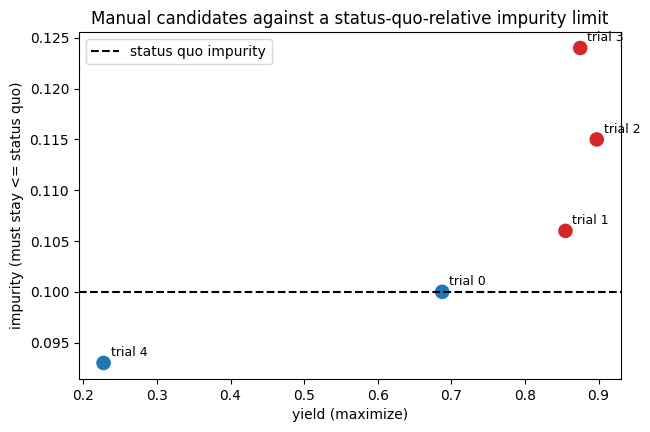

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = df["feasible_vs_status_quo"].map({True: "tab:blue", False: "tab:red"})
ax.scatter(df["yield"], df["impurity"], c=colors, s=90)

for _, row in df.iterrows():
    ax.annotate(
        f"trial {int(row['trial_index'])}",
        (row["yield"], row["impurity"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax.axhline(baseline_impurity, color="black", linestyle="--", label="status quo impurity")
ax.set_title("Manual candidates against a status-quo-relative impurity limit")
ax.set_xlabel("yield (maximize)")
ax.set_ylabel("impurity (must stay <= status quo)")
ax.legend()
plt.show()


## What This Demonstrates

- `status_quo` is stored on the experiment as the baseline reference point.
- Relative outcome constraints are encoded by using `%` in the constraint string.
- You can manually evaluate the status quo first, then compare all later candidates to it.

For CEID, this is the Ax-native pattern you would use when the current production recipe
is a hard reference that new candidates should not regress from.
